# Logistic Regression - Diabetes Classification

This notebook implements the Logistic Regression model for the diabetes classification problem.

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

np.random.seed(42)

In [2]:
# Load the dataset
df = pd.read_csv("../dataset/diabetes_prediction_dataset_2000.csv")
df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,13.0,0,0,No Info,20.82,5.8,126,0
1,Female,3.0,0,0,No Info,21.00,5.0,145,0
2,Male,63.0,0,0,former,25.32,3.5,200,0
3,Female,2.0,0,0,never,17.43,6.1,126,0
4,Female,33.0,0,0,not current,40.08,6.2,200,1


In [3]:
# Basic dataset audit
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4


In [4]:
#Removing duplicates
df = df.drop_duplicates()
print("Shape After Removing duplicates:", df.shape)

Shape After Removing duplicates: (1996, 9)


In [5]:
# Check the target distribution
print("Diabetes counts:")
print(df["diabetes"].value_counts())

print("\nPercentage of each class:")
print((df["diabetes"].value_counts(normalize=True) * 100).round(2))

Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


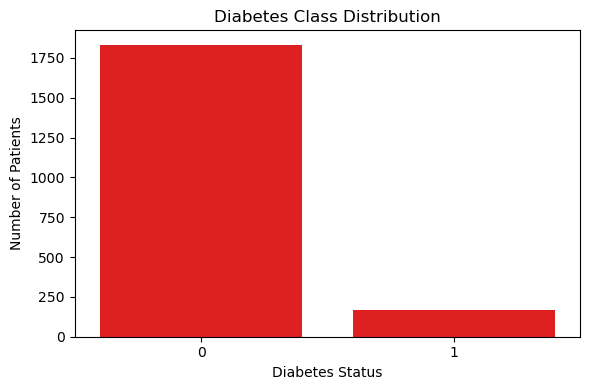

In [6]:
# Diabetes class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diabetes",color='red')
plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

### Insight

The target distribution shows the number of patients in each diabetes class. This is useful for checking whether the classification problem is balanced or whether one class is represented more heavily than the other.

In [7]:
# Remove duplicate records
before = len(df)
df = df.drop_duplicates()
after = len(df)

print("Rows before removing duplicates:", before)
print("Duplicate rows removed:", before - after)
print("Rows after removing duplicates:", after)

Rows before removing duplicates: 1996
Duplicate rows removed: 0
Rows after removing duplicates: 1996


In [8]:
# Check and handle missing values
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values were found, no imputation was required.")
else:
    num_missing_cols = df.select_dtypes(include=np.number).columns
    cat_missing_cols = df.select_dtypes(exclude=np.number).columns

    for col in num_missing_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

    for col in cat_missing_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])

    print("Missing values were handled using median imputation for numerical columns and mode for categorical columns.")
print("\nMissing values after cleaning:")
print(df.isnull().sum())

No missing values were found, no imputation was required.

Missing values after cleaning:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [9]:
outlier_cols = [
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

outlier_summary = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outliers Found": count
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,Feature,Lower Bound,Upper Bound,Outliers Found
0,bmi,14.66375,38.61375,143
1,HbA1c_level,2.70000,8.30000,22
2,blood_glucose_level,11.50000,247.50000,33


In [10]:
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    remaining = ((df[col] < lower) | (df[col] > upper)).sum()
    print(col, "Outliers After Treatment:", remaining)

bmi Outliers After Treatment: 143
HbA1c_level Outliers After Treatment: 22
blood_glucose_level Outliers After Treatment: 33


In [11]:

# Numerical features
num_cols = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

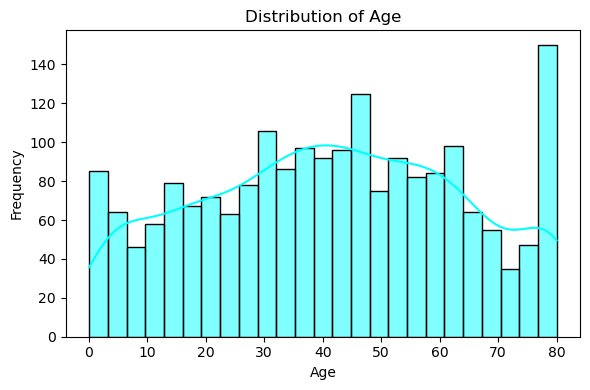

In [12]:
# Age distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["age"], bins=25, kde=True,color='aqua')
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight

The age distribution shows how the patients are spread across different age groups. The shape of this distribution helps us understand whether the dataset contains mostly younger, middle-aged, or older patients.

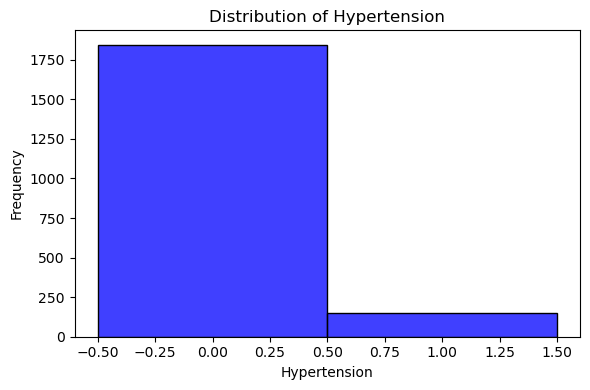

In [13]:
# Hypertension distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["hypertension"], bins=3, discrete=True,color='blue')
plt.title("Distribution of Hypertension")
plt.xlabel("Hypertension")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight

Hypertension is a binary health indicator. The distribution shows how many patients have hypertension compared with those who do not.

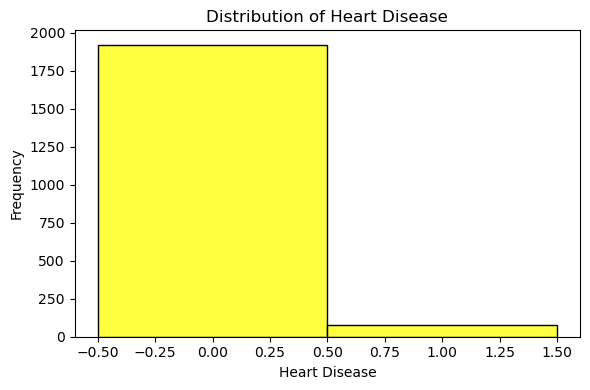

In [14]:
# Heart disease distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["heart_disease"], bins=3, discrete=True,color='yellow')
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight

Heart disease is also represented as a binary feature,because it only has two values 0 and 1. The plot shows the relative number of patients with and without the condition in the dataset.

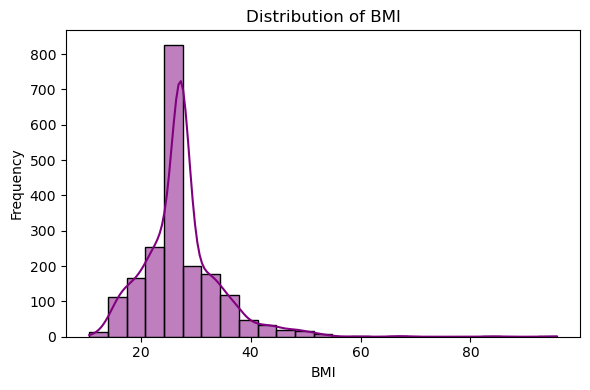

In [15]:
# BMI distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["bmi"], bins=25, kde=True,color='purple')
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight

The BMI distribution shows the range and concentration of body-mass values.The shape also helps to identify whether the values are concentrated around a particular range or they are skewed.

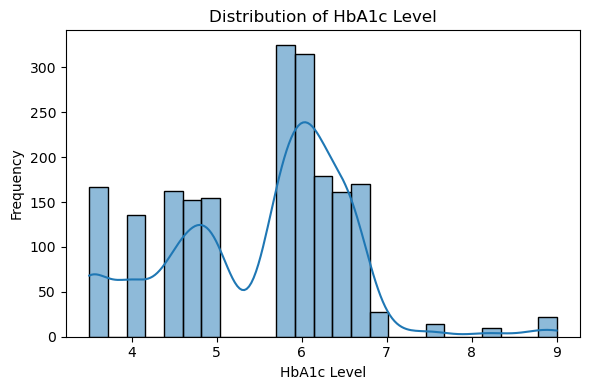

In [16]:
# HbA1c distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["HbA1c_level"], bins=25, kde=True)
plt.title("Distribution of HbA1c Level")
plt.xlabel("HbA1c Level")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight

The HbA1c distribution shows how this blood-sugar-related measurement varies among the patients. Its spread is useful when studying its relationship with the diabetes target.

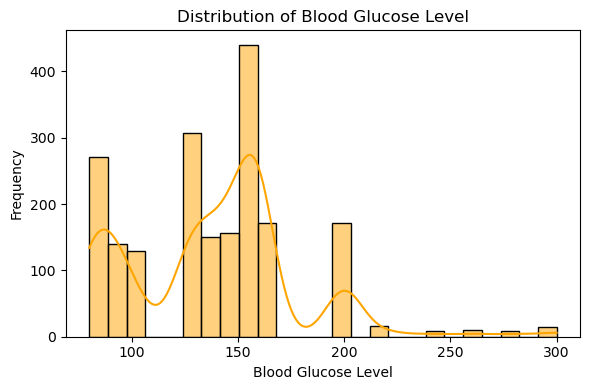

In [17]:
# Blood glucose distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["blood_glucose_level"], bins=25, kde=True,color='orange')
plt.title("Distribution of Blood Glucose Level")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight

The blood glucose distribution shows the range of glucose measurements. This feature is used, because glucose level is directly related to the diabetes classification problem.

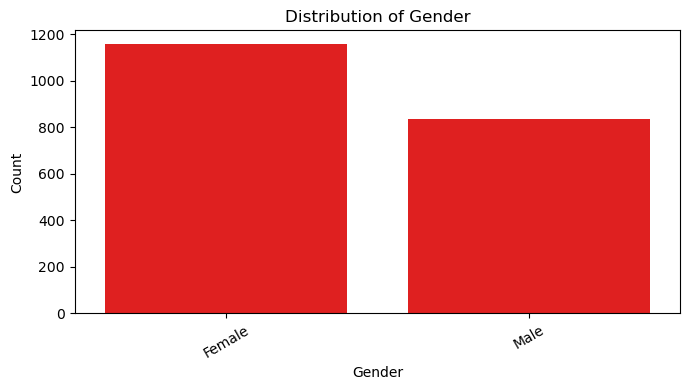

In [18]:
# Gender distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="gender",color='red')
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Insight

The gender plot shows the number of records in each category. It also helps to identify whether one category is more represented than the others.

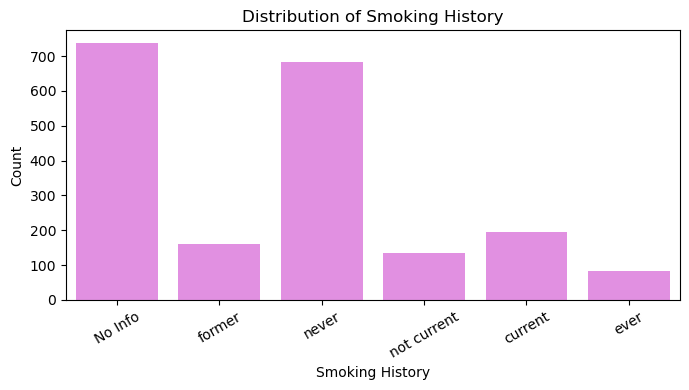

In [19]:
# Smoking history distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="smoking_history",color='violet')
plt.title("Distribution of Smoking History")
plt.xlabel("Smoking History")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Insight

The smoking history plot shows how the patient records are distributed across the available smoking categories. This provides an overview of the categorical information.

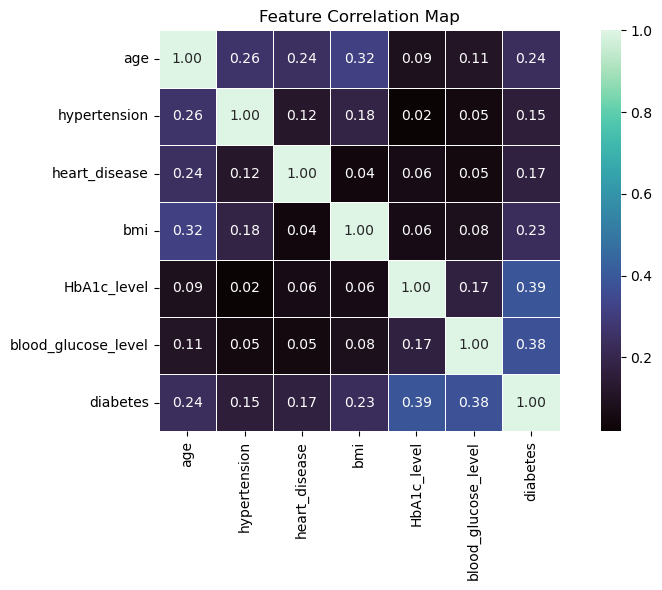

In [20]:
# Correlation heatmap
corr = df[num_cols + ["diabetes"]].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="mako",
    linewidths=0.6,
    square=True
)
plt.title("Feature Correlation Map")
plt.tight_layout()
plt.show()

### Insight
The correlation heatmap summarizes the linear relationships among the numerical variables and the diabetes target because, the diabetes column can be compared with each numerical feature to identify which variables have stronger or weaker linear association with the target variable y.

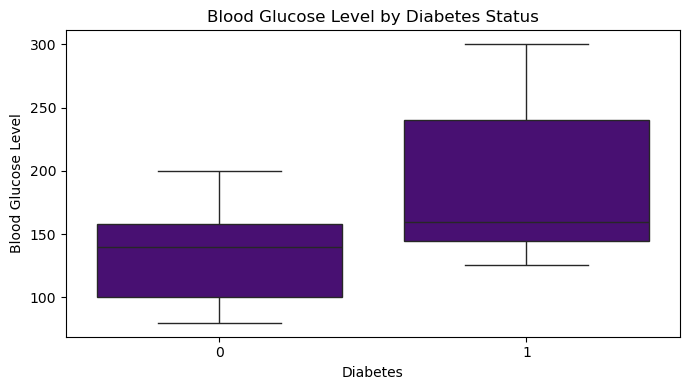

In [21]:
# Blood glucose level by diabetes status
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="diabetes", y="blood_glucose_level",color='indigo')
plt.title("Blood Glucose Level by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("Blood Glucose Level")
plt.tight_layout()
plt.show()

### Insight

This boxplot compares blood glucose levels between the two diabetes classes. Differences in the central values are spread between the groups indicate that blood glucose level.

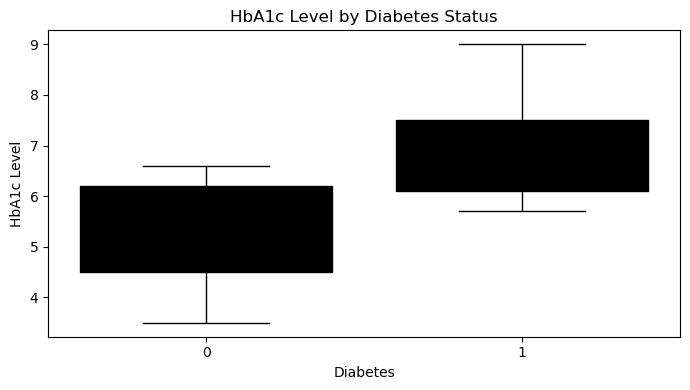

In [22]:
# HbA1c level by diabetes status
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="diabetes", y="HbA1c_level",color='black')
plt.title("HbA1c Level by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("HbA1c Level")
plt.tight_layout()
plt.show()

### Insight

The HbA1c plot compares the distribution of HbA1c values for the two diabetes classes.The difference between the groups suggests that this feature may help the classifier distinguish between the classes.

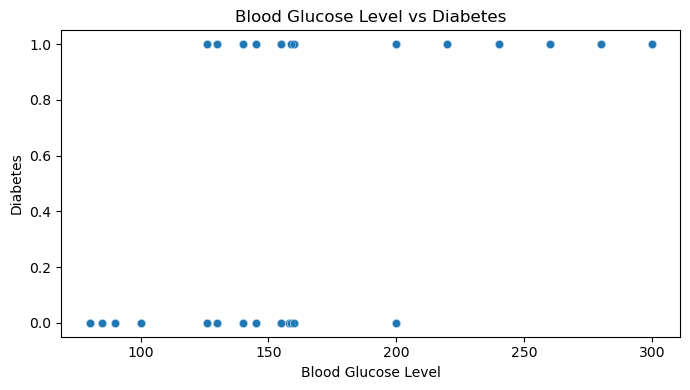

In [23]:
# Scatter plot: Blood glucose vs diabetes
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=df,
    x="blood_glucose_level",
    y="diabetes",
    alpha=0.45
)
plt.title("Blood Glucose Level vs Diabetes")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Diabetes")
plt.tight_layout()
plt.show()

### Insight

The scatter plot shows how diabetes labels are distributed across blood glucose levels. The separation of points between the two target classes gives an indication of whether blood glucose level can help distinguish diabetes status.

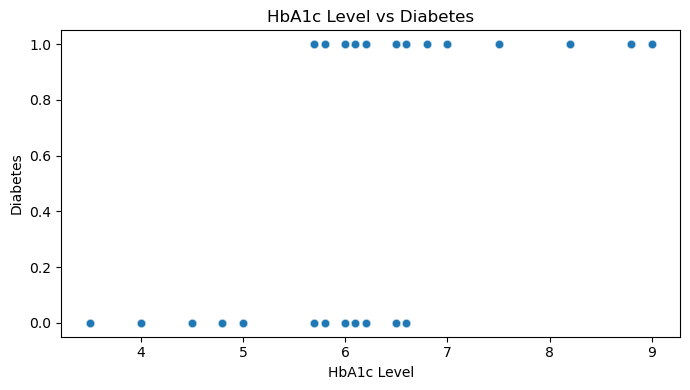

In [24]:
# Scatter plot: HbA1c vs diabetes
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=df,
    x="HbA1c_level",
    y="diabetes",
    alpha=0.45
)
plt.title("HbA1c Level vs Diabetes")
plt.xlabel("HbA1c Level")
plt.ylabel("Diabetes")
plt.tight_layout()
plt.show()

### Insight

This scatter plot shows the relationship between HbA1c level and the target diabetes. The distribution of points across the two target values helps to indicate whether higher or lower HbA1c values are associated with other diabetes classes.

In [25]:
# Create an engineered feature
df["glucose_hba1c_interaction"] = (
    df["blood_glucose_level"] * df["HbA1c_level"]
)
print("Engineered feature created: glucose_hba1c_interaction")
df[["blood_glucose_level", "HbA1c_level", "glucose_hba1c_interaction"]].head()

Engineered feature created: glucose_hba1c_interaction


,blood_glucose_level,HbA1c_level,glucose_hba1c_interaction
0,126,5.8,730.8
1,145,5.0,725.0
2,200,3.5,700.0
3,126,6.1,768.6
4,200,6.2,1240.0


In [26]:
# Separate features and target
x = df.drop("diabetes", axis=1)
y = df["diabetes"]

print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (1996, 9)
Target shape: (1996,)


In [27]:
# Stratified train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training data: (1596, 9)
Testing data: (400, 9)

Training target distribution:
diabetes
0    0.917
1    0.083
Name: proportion, dtype: float64

Testing target distribution:
diabetes
0    0.918
1    0.082
Name: proportion, dtype: float64


In [28]:
#Preprocessing method
num_features = ["age","hypertension","heart_disease","bmi","HbA1c_level","blood_glucose_level","glucose_hba1c_interaction"]
cat_features = ["gender", "smoking_history"]
prep = ColumnTransformer(transformers=[("numerical",StandardScaler(),num_features),("categorical",OneHotEncoder(handle_unknown="ignore"),cat_features)])

In [29]:
#Building the Logistic Regression model
lr_model = Pipeline(steps=[("preprocessing", prep),("logistic",LogisticRegression(max_iter=1000,random_state=42))])

In [30]:
# Train the model
lr_model.fit(x_train, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [31]:
# Generate predictions
lr_pred = lr_model.predict(x_test)
lr_prob = lr_model.predict_proba(x_test)[:, 1]

print("First 10 predictions:")
print(lr_pred[:10])

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]


In [32]:
# Calculate evaluation metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, zero_division=0)
lr_recall = recall_score(y_test, lr_pred, zero_division=0)
lr_f1 = f1_score(y_test, lr_pred, average="weighted")
lr_auc = roc_auc_score(y_test, lr_prob)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy    :", lr_accuracy)
print("Precision   :", lr_precision)
print("Recall      :", lr_recall)
print("Weighted F1 :", lr_f1)
print("ROC-AUC     :", lr_auc)

Logistic Regression Results
---------------------------
Accuracy    : 0.945
Precision   : 0.7619047619047619
Recall      : 0.48484848484848486
Weighted F1 : 0.9393312481382187
ROC-AUC     : 0.9435224176368591


In [33]:
# Classification report
print(classification_report(y_test,lr_pred,zero_division=0))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       367
           1       0.76      0.48      0.59        33

    accuracy                           0.94       400
   macro avg       0.86      0.74      0.78       400
weighted avg       0.94      0.94      0.94       400



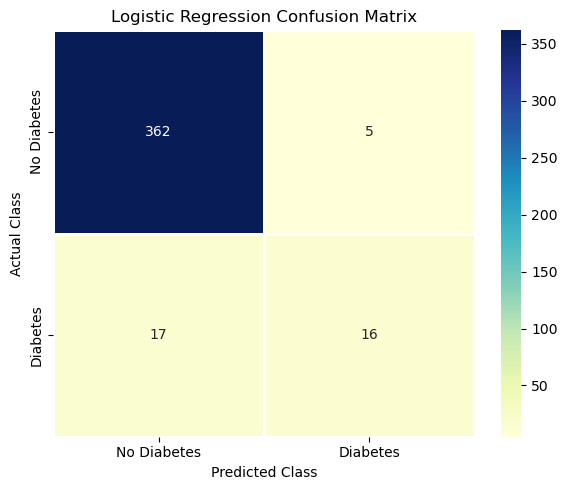

In [34]:
# Confusion matrix
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.8,
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

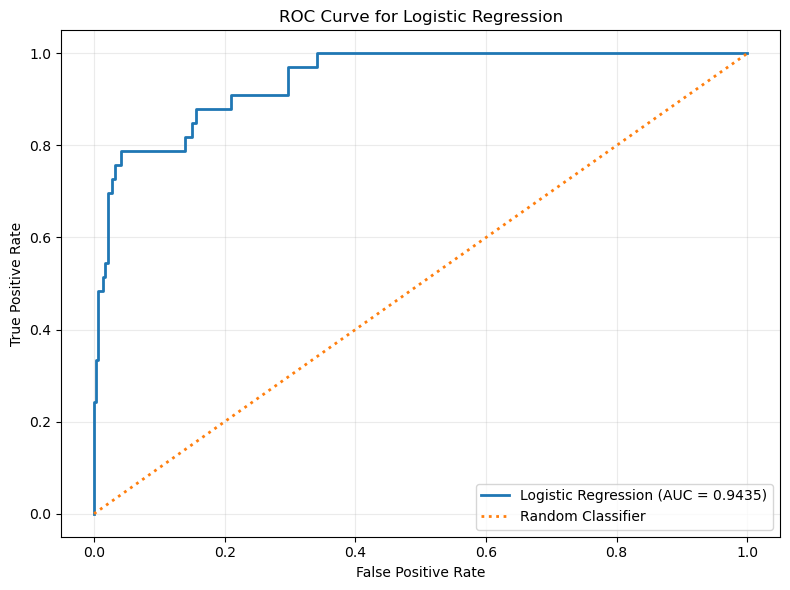

In [35]:
# ROC curve
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, lr_prob)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {lr_auc:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    linewidth=2,
    label="Random Classifier"
)
plt.title("ROC Curve for Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Insight

The ROC curve shows the trade off between the true positive rate(TRP) and false positive rate(FPR) at different thresholds. The AUC value gives the model's ability to distinguish between the two diabetes classes.

In [39]:
import pandas as pd

results_path = "../results/classification_results.csv"
results = pd.read_csv(results_path)
results = results[results["Model"] == "Logistic Regression"]
results.reset_index(drop=True)

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Logistic Regression,0.945,0.761905,0.484848,0.939331,0.943522
